In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

California Housing Dataset

In [3]:
data = pd.read_csv("housing.csv")

In [4]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


DATA EXPLORATION


Data Cleaning

In [5]:
data.drop

<bound method DataFrame.drop of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  median_house_value  \
0           322.0       126.0         8.3252            452600.0   
1          2401.0      1138.0         8.3014            358500.0   
2           496.0       177.0         7.2574            352100.0   
3           558.0       219.0         5.6431            341300.0   
4           565.0       259.0         3.8462            342200.0   
...           ...         ...            ...                 ...   
20635       845.0       330.0         1.5603             78100.0   
20636       356.0       114.0         2.5568             77100.0   
20637      1007.0       433.0         1.7000             92300.0   
20638       741.0       349.0         1.8672             84700.0   
20639      1387.0       530.0         2.3886             89400.0   

      ocean_proximity  
0            NEAR BAY  
1            NEAR BAY  
2            NEAR BAY  
3            NEAR BAY  
4            NEAR BAY  
...               ...  
20635          INLAND  
20636          INLAND  
20637          INLAND  
20638          INLAND  
20639          INLAND  

[20640 rows x 10 columns]>

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


removing null data

In [7]:
data.dropna(inplace=True)

we have removed null data

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


SPLIT THE DATA INTO X AND Y FOR TRAINING AND TESTING DATA

In [28]:
from sklearn.model_selection import train_test_split

x= data.drop(['median_house_value'], axis=1)
y= data['median_house_value']

In [29]:
x

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND


In [30]:
y

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0
...,...
20635,78100.0
20636,77100.0
20637,92300.0
20638,84700.0


In [ ]:
#create train-test data

In [31]:
x_train_raw,x_test_raw,y_train_raw,y_test_raw = train_test_split(x,y,test_size=0.2, random_state=42)

In [32]:
train_data = x_train.join(y_train)

In [33]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,342200.0
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND,84700.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

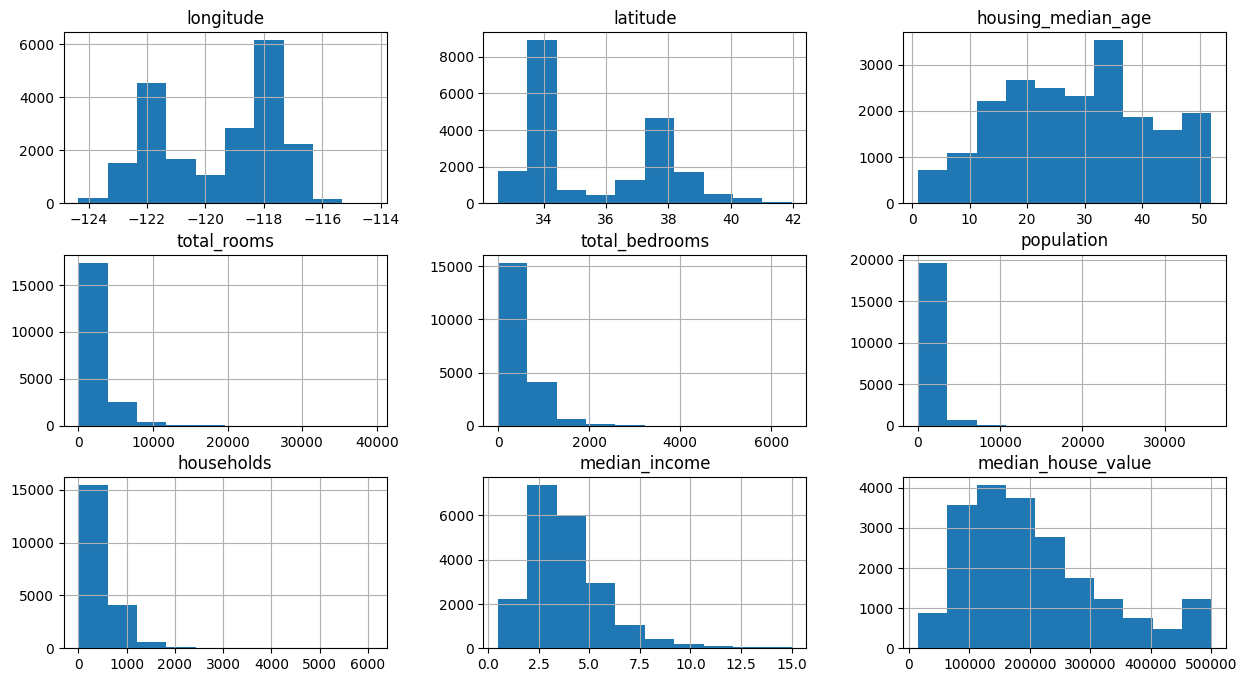

In [34]:
train_data.hist(figsize=(15,8))

we going to say s and s heat map we're going to use a heat map to visualize a correlation matrix   

because ocean_proximity we have found that is string so we shold drop it because correlation is only done by numerical value

In [35]:
train_data.drop('ocean_proximity', axis=1).corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000


Exploratory Data Analysis

<Axes: >

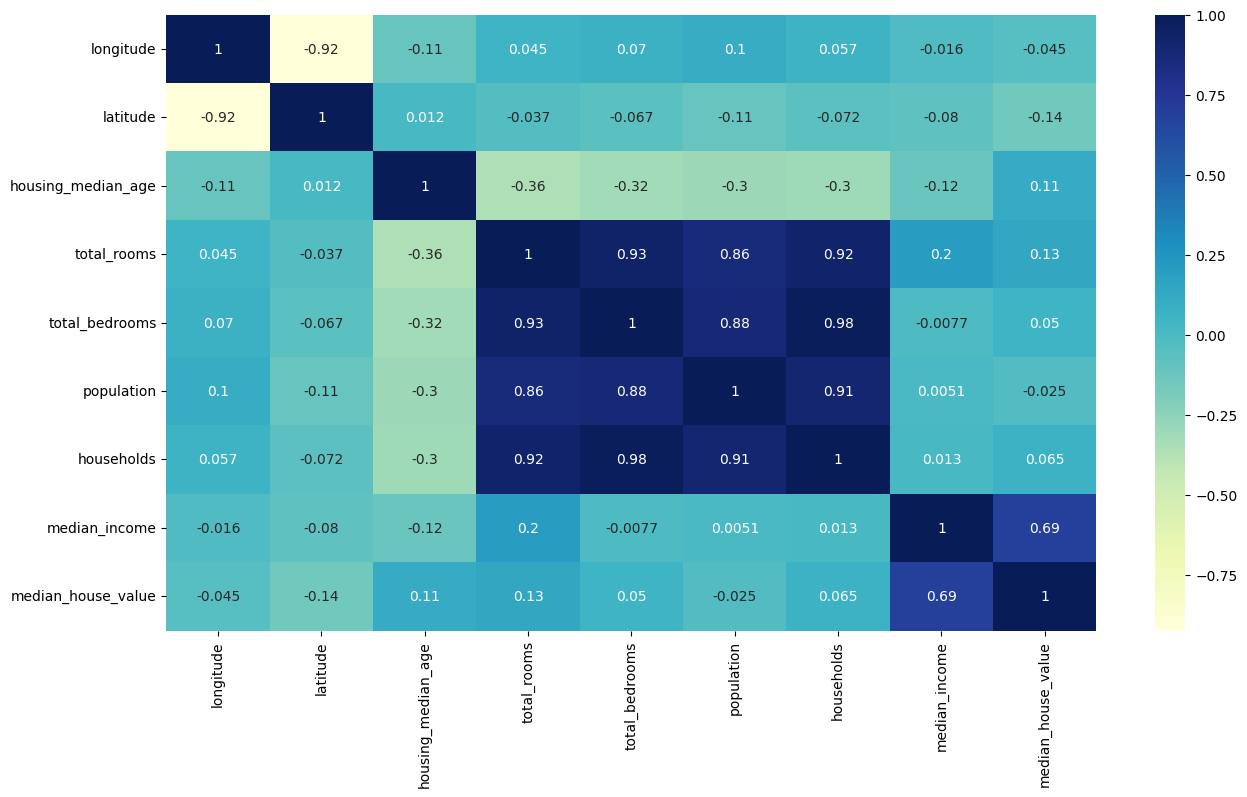

In [36]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.drop('ocean_proximity', axis=1).corr(), annot=True, cmap="YlGnBu")

DATA PREPROCESSING

Log Transformation

In [37]:
train_data['total_rooms'] = np.log(train_data['total_rooms']+1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms']+1)
train_data['population'] = np.log(train_data['population']+1)
train_data['households'] = np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

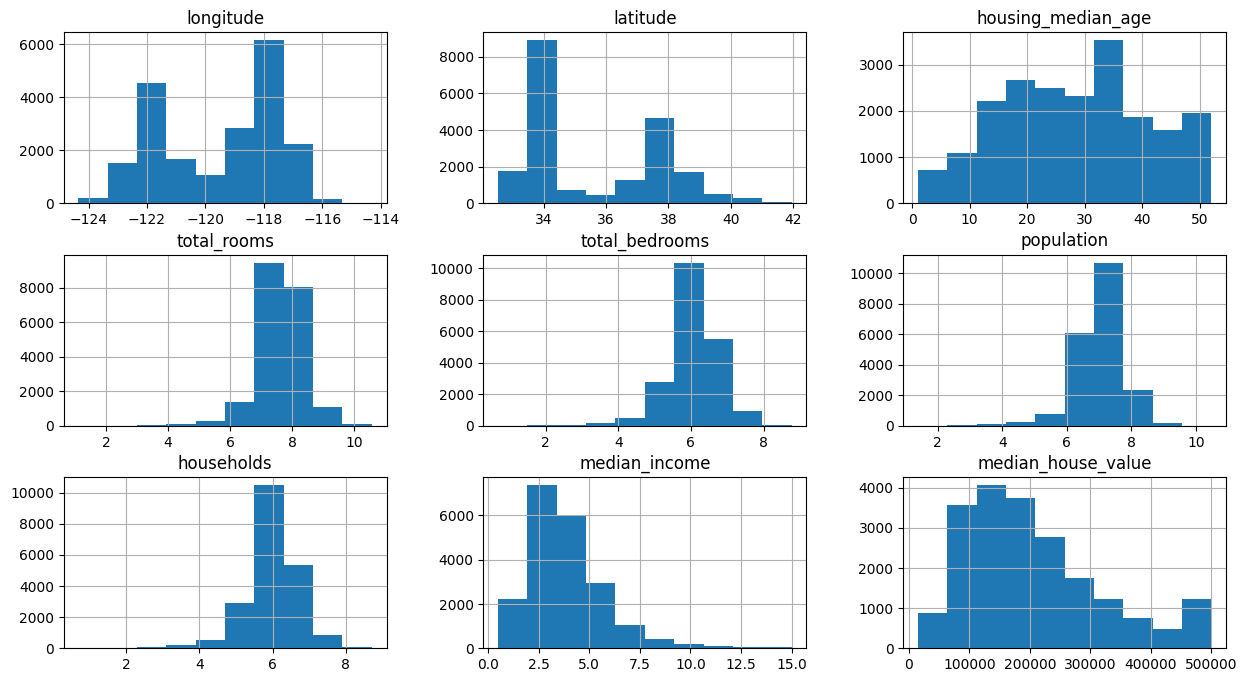

In [38]:
train_data.hist(figsize=(15,8))

this is like a gaussian bell curve

In [39]:
train_data.ocean_proximity.value_counts()

,count
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


In [40]:
pd.get_dummies(train_data.ocean_proximity)

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,False,False,False,True,False
1,False,False,False,True,False
2,False,False,False,True,False
3,False,False,False,True,False
4,False,False,False,True,False
...,...,...,...,...,...
20635,False,True,False,False,False
20636,False,True,False,False,False
20637,False,True,False,False,False
20638,False,True,False,False,False


this data now can join with our train data

In [41]:
train_data.join(pd.get_dummies(train_data.ocean_proximity))

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,NEAR BAY,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,NEAR BAY,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,NEAR BAY,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,NEAR BAY,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,NEAR BAY,342200.0,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,7.418181,5.926926,6.740519,5.802118,1.5603,INLAND,78100.0,False,True,False,False,False
20636,-121.21,39.49,18.0,6.548219,5.017280,5.877736,4.744932,2.5568,INLAND,77100.0,False,True,False,False,False
20637,-121.22,39.43,17.0,7.720905,6.186209,6.915723,6.073045,1.7000,INLAND,92300.0,False,True,False,False,False
20638,-121.32,39.43,18.0,7.528869,6.016157,6.609349,5.857933,1.8672,INLAND,84700.0,False,True,False,False,False


after we join data now we have a categories and we are going to drop afterward the ocean proximity and we save them into train data

In [42]:
train_data=train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(['ocean_proximity'],axis=1)

In [43]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,7.418181,5.926926,6.740519,5.802118,1.5603,78100.0,False,True,False,False,False
20636,-121.21,39.49,18.0,6.548219,5.017280,5.877736,4.744932,2.5568,77100.0,False,True,False,False,False
20637,-121.22,39.43,17.0,7.720905,6.186209,6.915723,6.073045,1.7000,92300.0,False,True,False,False,False
20638,-121.32,39.43,18.0,7.528869,6.016157,6.609349,5.857933,1.8672,84700.0,False,True,False,False,False


now we can take heatmap and correrate and see how these new features correlate with a target variable

<Axes: >

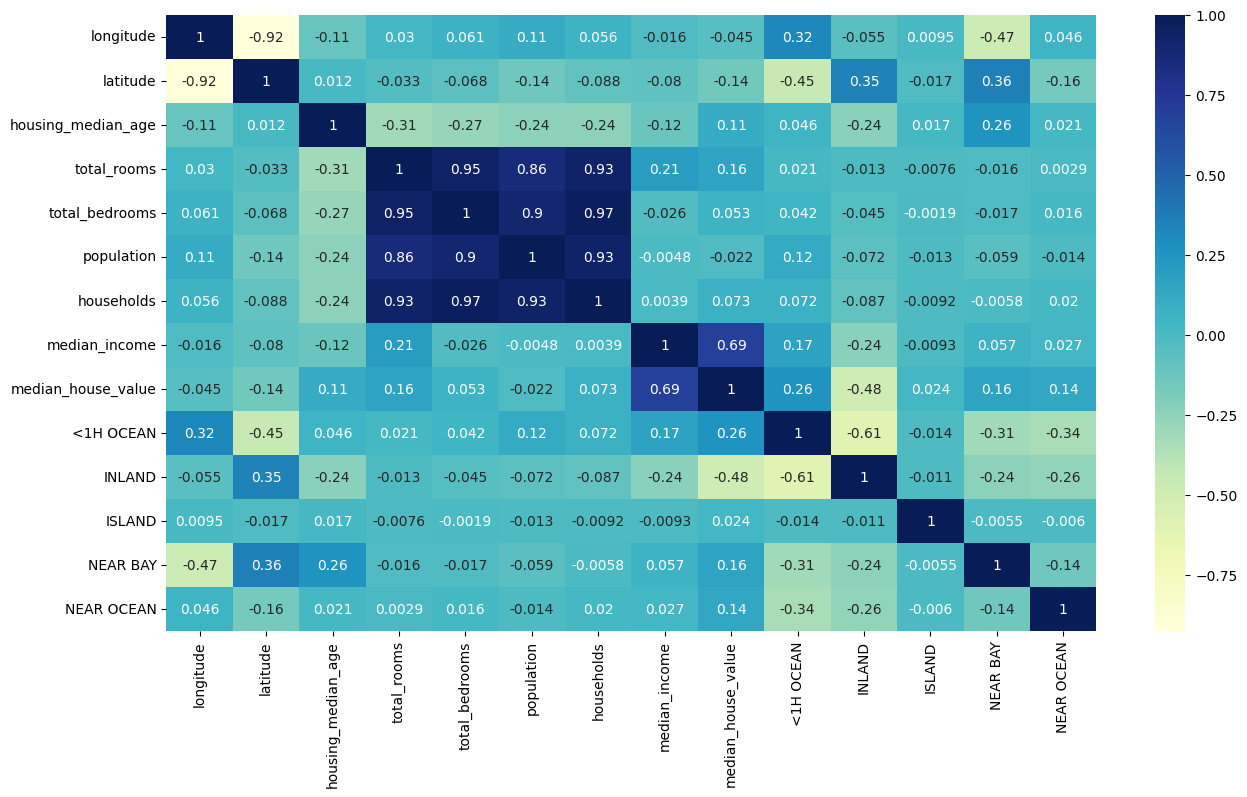

In [44]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

how these new features correlate with a target variable for example in INLAND with target variable(median house have negative correlation with INLAND) SO IF YOURE INLAND YOU PAY LESS WAY LESS FOR YOUR HOUSE OR THE MEDEIAN PRICE IN THE BLOCK WAY LOWER THAN IF ITS NOT INLAND AND AND THE SAME OR OPPOSSITE IS TRUE FOR LESS THAN ONE HOUR AWAY FROM THE OCEAN THIS IS USUALLY A HIGHER PRICE

Visualize the coordinate before feature engenering

<Axes: xlabel='longitude', ylabel='latitude'>

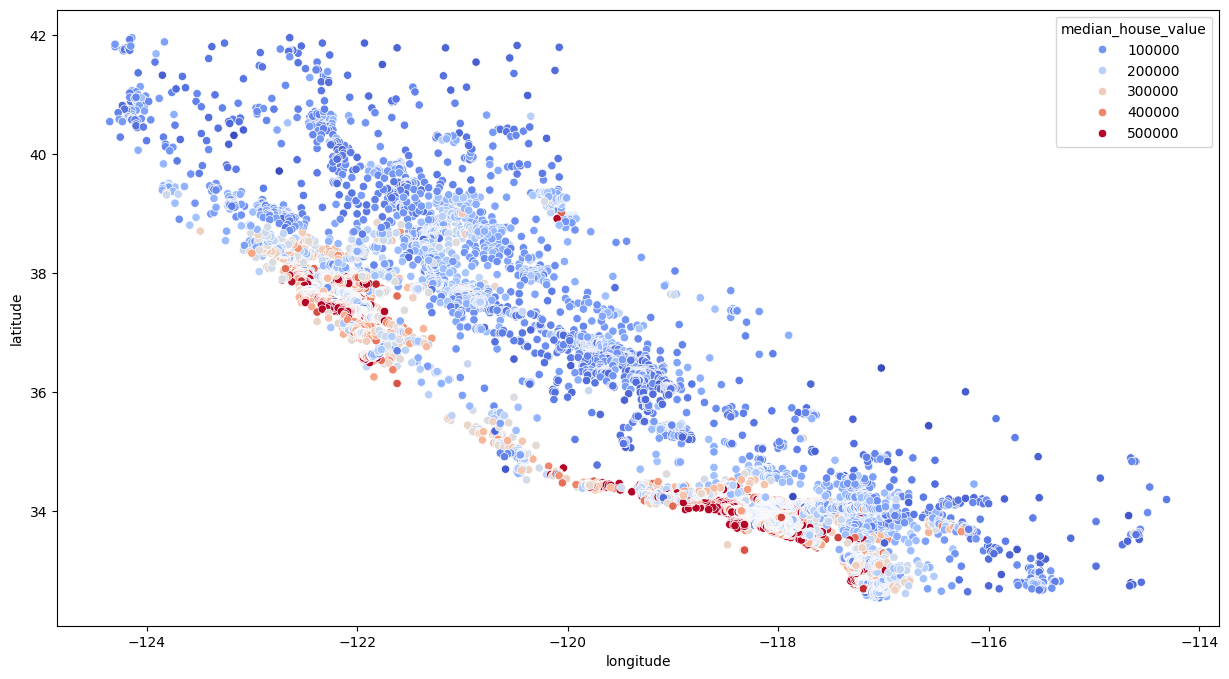

In [45]:
plt.figure(figsize=(15,8))
sns.scatterplot(data=train_data, x='longitude', y='latitude', hue='median_house_value', palette='coolwarm')

in the key its means the median house value so the more red it gets the more expensive the houses and the more blue it is the less expensive the houses and down their its is the coast so this will be are inland

FEATURE ENGINEERING

how many bedroom are equal to each room also we can add other feature household

In [46]:
train_data['bedroom_ratio'] = train_data['total_bedrooms']/train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms']/train_data['households']

<Axes: >

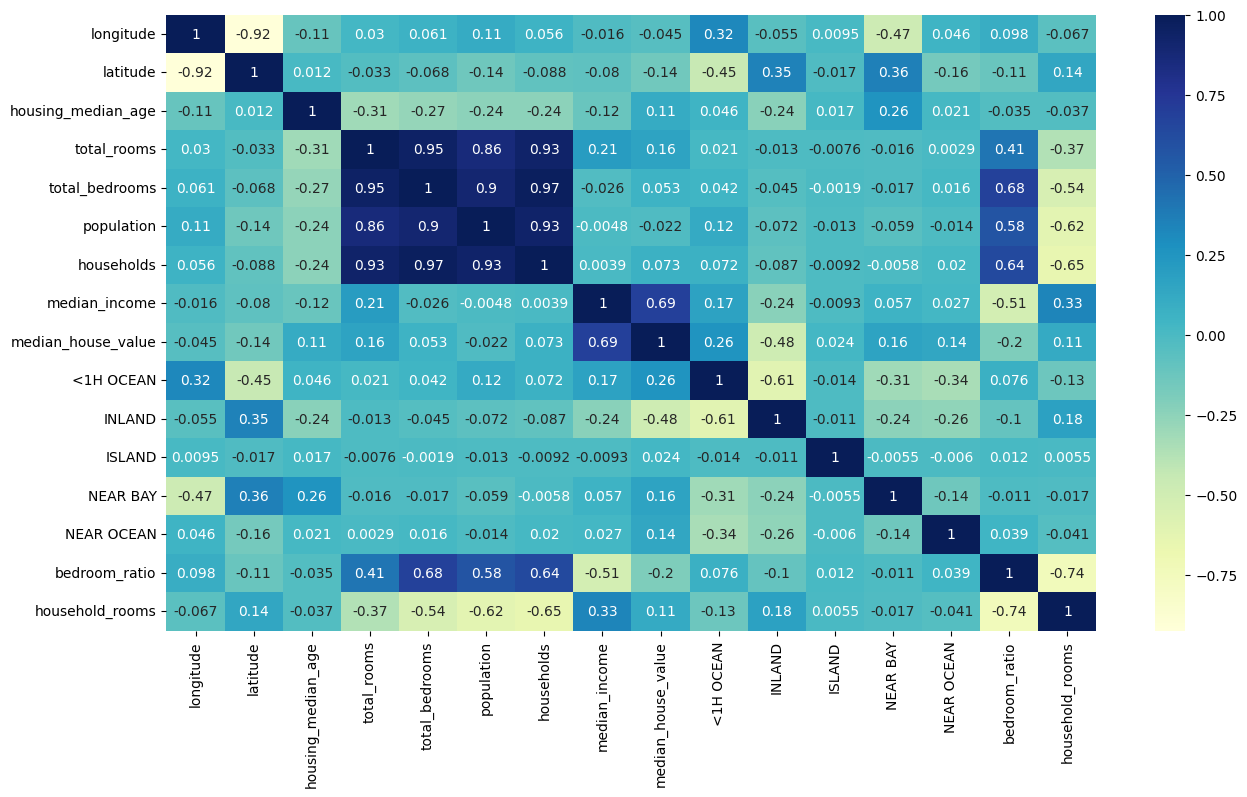

In [47]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

we compare those features to targert varibalr but also you can come up with new features  drop features oftentimes its make the model betterif you drop features that have close to zero correlation with the target variable

MODEL(LINEAR REGRESSION)

In [68]:
from sklearn.linear_model import LinearRegression

# Removed line: x_train,y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']
reg = LinearRegression()
reg.fit(x_train_processed, y_train_processed) # Use the processed data from cell 814e4acb

LinearRegression()

Now that the training data (`x_train_processed`, `y_train_processed`) is fully prepared, let's fit the Linear Regression model.

In [69]:
from sklearn.linear_model import LinearRegression

# Initialize and fit the Linear Regression model
reg = LinearRegression()
reg.fit(x_train_processed, y_train_processed)

print("Linear Regression model fitted successfully.")

Linear Regression model fitted successfully.


With the model fitted and the test data (`x_test_processed`, `y_test_processed`) also fully prepared, we can now evaluate the model's performance.

In [79]:
# Evaluate the model with the consistently processed test data
score = reg.score(x_test_processed, y_test_processed)
print(f"The R-squared score is: {score}")

The R-squared score is: 0.6687407117584969


The previous steps for `train_data`'s preprocessing were not fully reflected in the `x_train` used for model fitting. To ensure consistent preprocessing, we will re-apply the log transformations and feature engineering to `train_data`, and then re-extract `x_train` and `y_train`.

In [80]:
# This cell now assumes 'x_train_raw' and 'y_train_raw' are the raw splits from train_test_split.

train_data_initial = x_train_raw.join(y_train_raw)

# Apply log transformations
train_data_initial['total_rooms'] = np.log(train_data_initial['total_rooms']+1)
train_data_initial['total_bedrooms'] = np.log(train_data_initial['total_bedrooms']+1)
train_data_initial['population'] = np.log(train_data_initial['population']+1)
train_data_initial['households'] = np.log(train_data_initial['households']+1)

# Apply one-hot encoding for ocean_proximity and drop the original
train_data_full_processed = train_data_initial.join(pd.get_dummies(train_data_initial.ocean_proximity, dtype=bool)).drop('ocean_proximity', axis=1)

# Engineer new features
train_data_full_processed['bedroom_ratio'] = train_data_full_processed['total_bedrooms']/train_data_full_processed['total_rooms']
train_data_full_processed['household_rooms'] = train_data_full_processed['total_rooms']/train_data_full_processed['households']

# Extract x_train_processed and y_train_processed from the fully processed data
x_train_processed = train_data_full_processed.drop(['median_house_value'], axis=1)
y_train_processed = train_data_full_processed['median_house_value']

print("Training data fully processed.")

Training data fully processed.


Now, we will apply the *exact same* preprocessing steps to the test data to ensure consistency with the training data for evaluation.

In [81]:
# This cell now assumes 'x_test_raw' and 'y_test_raw' are the raw splits from train_test_split.

test_data_initial = x_test_raw.join(y_test_raw)

# Apply log transformations
test_data_initial['total_rooms'] = np.log(test_data_initial['total_rooms']+1)
test_data_initial['total_bedrooms'] = np.log(test_data_initial['total_bedrooms']+1)
test_data_initial['population'] = np.log(test_data_initial['population']+1)
test_data_initial['households'] = np.log(test_data_initial['households']+1)

# Apply one-hot encoding for ocean_proximity and drop the original
test_data_full_processed = test_data_initial.join(pd.get_dummies(test_data_initial.ocean_proximity, dtype=bool)).drop('ocean_proximity', axis=1)

# Engineer new features
test_data_full_processed['bedroom_ratio'] = test_data_full_processed['total_bedrooms']/test_data_full_processed['total_rooms']
test_data_full_processed['household_rooms'] = test_data_full_processed['total_rooms']/test_data_full_processed['households']

# Extract x_test_processed and y_test_processed from the fully processed data
x_test_processed = test_data_full_processed.drop(['median_house_value'], axis=1)
y_test_processed = test_data_full_processed['median_house_value']

print("Test data fully processed.")

Test data fully processed.


Now, let's evaluate the model's score using the consistently processed test data.

In [82]:
# Evaluate the model with the consistently processed test data
score = reg.score(x_test_processed, y_test_processed)
print(f"The R-squared score is: {score}")

The R-squared score is: 0.6687407117584969


we have train again beacause we warn consider new features but if you wwant to use those past train data you can:: for linear we going to do just evaluation but for the other model for the random forest regressor were are going to do hyper parameter tuning

RANDOM FOREST PROGRESSOR(MORE POWERFUL MODEL AND WERE GOING TO ALSO DO HYPER PARAMETER

In [83]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()
forest.fit(x_train_processed, y_train_processed)

RandomForestRegressor()

RandomforestRegssor

In [84]:
forest.score(x_test_processed, y_test_processed)

0.820827004061242

has high accuracy and were are going to use grid search with cross validation so cross validation to keep it simple means we take the data we split it into k folds k being a number and we use all but one fold to train the data and one for the evaluation so if we have 10 folds we use nine for training and 1 for testing and you do that for all possible combinations and the you evaluate the parameter

GridSearchCV

In [85]:
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor()
param_grid = {
        'n_estimators': [100, 200, 300],
        'min_samples_split': [2, 4],
        'min_samples_leaf': [1, 2],
        'max_depth': [None, 4, 8]

    }

grid_search = GridSearchCV(forest, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

grid_search.fit(x_train_processed, y_train_processed)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 4, 8], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 4],
                         'n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='neg_mean_squared_error')

now we can check if this best estimator actually produces better results its

Best Random Forest

In [87]:
grid_search.best_estimator_

RandomForestRegressor(min_samples_leaf=2, n_estimators=300)

Test Evaluation

In [88]:
grid_search.best_estimator_.score(x_test_processed,y_test_processed)

0.8224675433876283